# Section 6 — Copules et Contagion Extrême

In [1]:
import requests
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from arch import arch_model
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 130
})

DATA_DIR = os.getcwd()
print(f'Dossier de travail : {DATA_DIR}')

Dossier de travail : c:\Users\taham\Desktop\memoire


In [ ]:


def get_binance_klines(symbol, interval, start, end):
    url = 'https://api.binance.com/api/v3/klines'
    start_ms = int(pd.Timestamp(start).timestamp() * 1000)
    end_ms   = int(pd.Timestamp(end).timestamp()   * 1000)
    all_rows = []
    while start_ms < end_ms:
        params = {'symbol': symbol, 'interval': interval,
                  'startTime': start_ms, 'endTime': end_ms, 'limit': 1000}
        r = requests.get(url, params=params).json()
        if not r:
            break
        all_rows += r
        start_ms = r[-1][0] + 1
        if len(r) < 1000:
            break
    df = pd.DataFrame(all_rows, columns=[
        'time','open','high','low','close','volume',
        'close_time','qav','trades','tbbav','tbqav','ignore'
    ])
    df['time']  = pd.to_datetime(df['time'], unit='ms')
    df['close'] = df['close'].astype(float)
    return df[['time','close']].set_index('time')

print('Téléchargement BTC annuel...')
btc_annual = get_binance_klines('BTCUSDT', '1h', '2025-01-01', '2025-12-31')
print('Téléchargement ETH annuel...')
eth_annual = get_binance_klines('ETHUSDT', '1h', '2025-01-01', '2025-12-31')

df_annual = pd.DataFrame({
    'r_btc': np.log(btc_annual['close'] / btc_annual['close'].shift(1)),
    'r_eth': np.log(eth_annual['close'] / eth_annual['close'].shift(1))
}).dropna()

df_annual.to_csv(os.path.join(DATA_DIR, 'returns_btc_eth_2025_annual.csv'))
print(f'Données annuelles : {len(df_annual)} obs '
      f'({df_annual.index[0].date()} → {df_annual.index[-1].date()})')

Téléchargement BTC annuel...
Téléchargement ETH annuel...
Données annuelles : 8736 obs (2025-01-01 → 2025-12-31)


In [ ]:

def fetch_ohlcv_full(symbol, timeframe='1h', start='2025-10-01', end='2025-11-01'):
    exchange = ccxt.binance()
    since = exchange.parse8601(f'{start}T00:00:00Z')
    until = exchange.parse8601(f'{end}T00:00:00Z')
    all_data = []
    while since < until:
        ohlcv = exchange.fetch_ohlcv(symbol, timeframe, since=since, limit=1000)
        if not ohlcv:
            break
        all_data += ohlcv
        since = ohlcv[-1][0] + 1
    df = pd.DataFrame(all_data, columns=['timestamp','open','high','low','close','volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    return df[df.index < pd.Timestamp(end)]

print('Téléchargement BTC octobre...')
btc_oct = fetch_ohlcv_full('BTC/USDT')
print('Téléchargement ETH octobre...')
eth_oct = fetch_ohlcv_full('ETH/USDT')

btc_oct['returns'] = np.log(btc_oct['close']).diff()
eth_oct['returns'] = np.log(eth_oct['close']).diff()

print(f"Pire rendement BTC : {btc_oct['returns'].idxmin()} → {btc_oct['returns'].min()*100:.2f}%")
print(f"Pire rendement ETH : {eth_oct['returns'].idxmin()} → {eth_oct['returns'].min()*100:.2f}%")

# Dates exactes du crash 
CRASH_START = pd.Timestamp('2025-10-10 15:00:00')  # début ETH (−4.23%)
CRASH_PEAK  = pd.Timestamp('2025-10-10 20:00:00')  # pic BTC  (−2.07%)
CRASH_END   = pd.Timestamp('2025-10-11 03:00:00')  # fin cascade
print(f'\nFenêtre crash exacte : {CRASH_START} → {CRASH_END}')

Téléchargement BTC octobre...
Téléchargement ETH octobre...
Pire rendement BTC : 2025-10-10 20:00:00 → -2.07%
Pire rendement ETH : 2025-10-10 15:00:00 → -4.23%

Fenêtre crash exacte : 2025-10-10 15:00:00 → 2025-10-11 03:00:00


---
## Transformation en marges uniformes

**Méthode :**
1. EGARCH(1,1) sur les séries annuelles → résidus $z_t = \varepsilon_t / \hat{\sigma}_t$ (Section 4)
2. PIT empirique : $\hat{u}_t = \text{rang}(z_t^{BTC})/(n+1) \in (0,1)$

Les pseudo-observations $(\hat{u}_t, \hat{v}_t)$ isolent la **structure de dépendance pure**,
indépendamment des distributions marginales.

In [ ]:
def fit_egarch(returns: pd.Series, label: str):
    model  = arch_model(returns * 100, vol='EGARCH', p=1, q=1, dist='t')
    result = model.fit(disp='off')
    z = result.std_resid.dropna().values
    print(f'EGARCH {label} | '
          f'β={result.params["beta[1]"]:.3f}  '
          f'α={result.params["alpha[1]"]:.3f}  '
          f'ν={result.params["nu"]:.2f}  '
          f'AIC={result.aic:.1f}')
    return z

print('=== Estimation EGARCH(1,1) — données annuelles ===')
z_btc = fit_egarch(df_annual['r_btc'], 'BTC')
z_eth = fit_egarch(df_annual['r_eth'], 'ETH')

min_len = min(len(z_btc), len(z_eth))
z_btc, z_eth = z_btc[-min_len:], z_eth[-min_len:]
idx_aligned = df_annual.index[-min_len:]
print(f'\nRésidus alignés : {min_len} observations')

=== Estimation EGARCH(1,1) — données annuelles ===
EGARCH BTC | β=0.939  α=0.381  ν=3.33  AIC=7445.9
EGARCH ETH | β=0.954  α=0.269  ν=3.17  AIC=16608.8

Résidus alignés : 8736 observations


In [ ]:
def pit(z: np.ndarray) -> np.ndarray:
    """PIT empirique : rang / (n+1) → valeurs dans (0,1)."""
    return stats.rankdata(z) / (len(z) + 1)

u = pit(z_btc)
v = pit(z_eth)

print(f'û_t — min={u.min():.4f}  max={u.max():.4f}  mean={u.mean():.4f}')
print(f'v̂_t — min={v.min():.4f}  max={v.max():.4f}  mean={v.mean():.4f}')

crash_mask = (idx_aligned >= CRASH_START) & (idx_aligned <= CRASH_END)
print(f'\nPoints Flash Crash : {crash_mask.sum()} obs '
      f'({CRASH_START} → {CRASH_END})')

û_t — min=0.0001  max=0.9999  mean=0.5000
v̂_t — min=0.0001  max=0.9999  mean=0.5000

Points Flash Crash : 13 obs (2025-10-10 15:00:00 → 2025-10-11 03:00:00)


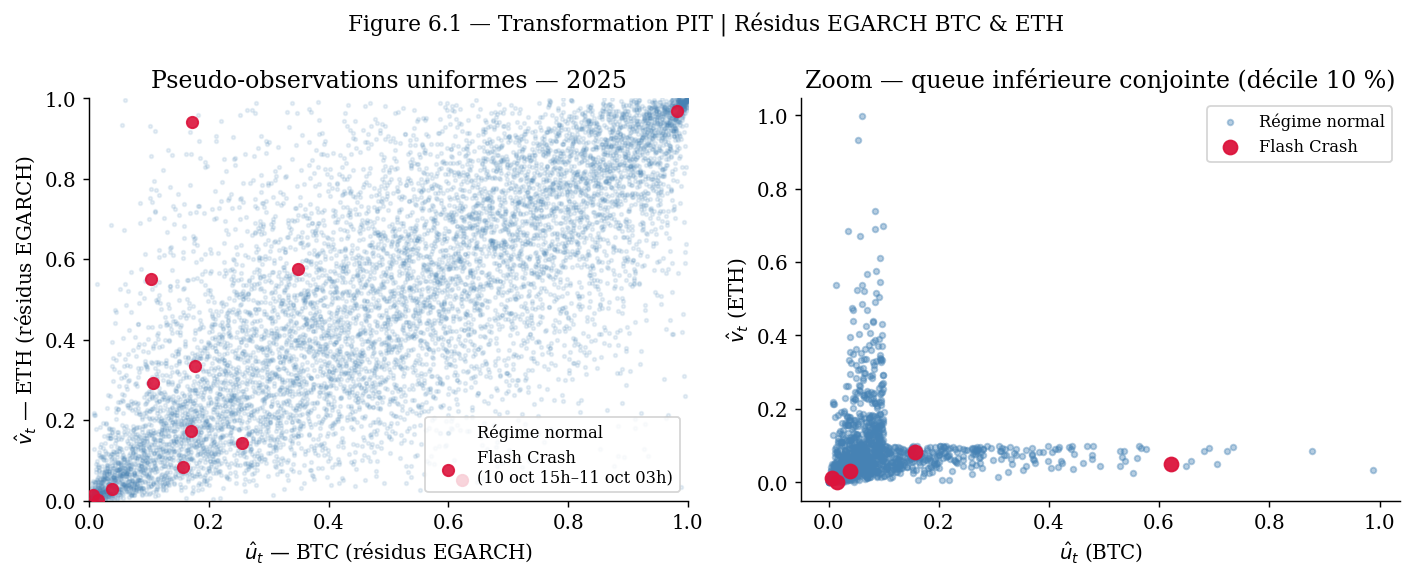

Figure 6.1 sauvegardée.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
ax.scatter(u[~crash_mask], v[~crash_mask], alpha=0.12, s=4,
           color='steelblue', label='Régime normal')
ax.scatter(u[crash_mask], v[crash_mask], alpha=0.9, s=40,
           color='crimson', zorder=5,
           label=f'Flash Crash\n({CRASH_START.strftime("%d oct %Hh")}–{CRASH_END.strftime("%d oct %Hh")})')
ax.set_xlabel(r'$\hat{u}_t$ — BTC (résidus EGARCH)')
ax.set_ylabel(r'$\hat{v}_t$ — ETH (résidus EGARCH)')
ax.set_title('Pseudo-observations uniformes — 2025')
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

ax = axes[1]
corner = (u < 0.10) | (v < 0.10)
ax.scatter(u[corner & ~crash_mask], v[corner & ~crash_mask],
           alpha=0.4, s=10, color='steelblue', label='Régime normal')
ax.scatter(u[corner & crash_mask], v[corner & crash_mask],
           alpha=0.95, s=60, color='crimson', zorder=5, label='Flash Crash')
ax.set_xlabel(r'$\hat{u}_t$ (BTC)')
ax.set_ylabel(r'$\hat{v}_t$ (ETH)')
ax.set_title('Zoom — queue inférieure conjointe (décile 10 %)')
ax.legend(fontsize=9)

fig.suptitle('Figure 6.1 — Transformation PIT | Résidus EGARCH BTC & ETH', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig6_1_pseudo_obs.pdf'), bbox_inches='tight')
plt.show()
print('Figure 6.1 sauvegardée.')

---
## 6.2 — Sélection et estimation des copules

Trois familles estimées par **MLE** sur les pseudo-observations annuelles :

| Famille | Paramètre | $\lambda_L$ | $\lambda_U$ | Profil |
|---------|-----------|------------|------------|--------|
| **Gaussienne** | $\rho \in (-1,1)$ | 0 | 0 | Dépendance linéaire, nulle en queue |
| **Clayton** | $\theta > 0$ | $2^{-1/\theta} > 0$ | 0 | Contagion sur les **pertes** |
| **Gumbel** | $\theta \geq 1$ | 0 | $2 - 2^{1/\theta} > 0$ | Contagion sur les **gains** |

In [ ]:
def fit_gaussian(u, v):
    def nll(params):
        rho = np.clip(params[0], -0.999, 0.999)
        x, y = stats.norm.ppf(u), stats.norm.ppf(v)
        ll = (-0.5*np.log(1 - rho**2)
              - (rho**2*(x**2 + y**2) - 2*rho*x*y) / (2*(1 - rho**2)))
        return -np.sum(ll)
    res = minimize(nll, [0.5], bounds=[(-0.999, 0.999)], method='L-BFGS-B')
    rho = np.clip(res.x[0], -0.999, 0.999)
    n   = len(u)
    return {'name': 'Gaussienne', 'params': {'ρ': rho},
            'nll': res.fun, 'aic': 2*res.fun + 2, 'bic': 2*res.fun + np.log(n),
            'λ_L': 0.0, 'λ_U': 0.0, 'τ': 2*np.arcsin(rho)/np.pi}

def fit_clayton(u, v):
    def nll(params):
        theta = max(params[0], 1e-6)
        ll = (np.log(1 + theta)
              + (-1 - theta)*(np.log(u) + np.log(v))
              + (-2 - 1/theta)*np.log(u**(-theta) + v**(-theta) - 1))
        return -np.sum(ll)
    res   = minimize(nll, [2.0], bounds=[(1e-6, 50)], method='L-BFGS-B')
    theta = max(res.x[0], 1e-6)
    n     = len(u)
    return {'name': 'Clayton', 'params': {'θ': theta},
            'nll': res.fun, 'aic': 2*res.fun + 2, 'bic': 2*res.fun + np.log(n),
            'λ_L': 2**(-1/theta), 'λ_U': 0.0, 'τ': theta/(theta + 2)}

def fit_gumbel(u, v):
    def nll(params):
        theta = max(params[0], 1.0 + 1e-6)
        A  = (-np.log(u))**theta + (-np.log(v))**theta
        C  = np.exp(-A**(1/theta))
        dC = (C / (u*v) * A**(2/theta - 2)
              * ((-np.log(u))*(-np.log(v)))**(theta - 1)
              * (A**(1/theta) + theta - 1))
        return -np.sum(np.log(np.maximum(dC, 1e-300)))
    res   = minimize(nll, [2.0], bounds=[(1.0 + 1e-6, 50)], method='L-BFGS-B')
    theta = max(res.x[0], 1.0 + 1e-6)
    n     = len(u)
    return {'name': 'Gumbel', 'params': {'θ': theta},
            'nll': res.fun, 'aic': 2*res.fun + 2, 'bic': 2*res.fun + np.log(n),
            'λ_L': 0.0, 'λ_U': 2 - 2**(1/theta), 'τ': 1 - 1/theta}

FIT_FNS = [fit_gaussian, fit_clayton, fit_gumbel]

# ── Estimation sur l'année complète ─────────────────────────────────────────
print('=== 6.2 — Estimation des copules (année complète) ===')
results_annual = [fn(u, v) for fn in FIT_FNS]

tab_annual = pd.DataFrame([{
    'Copule'    : r['name'],
    'Paramètre' : ', '.join(f'{k}={v_:.3f}' for k, v_ in r['params'].items()),
    'AIC'       : round(r['aic'], 1),
    'BIC'       : round(r['bic'], 1),
    'τ Kendall' : round(r['τ'], 3),
    'λ_L'       : round(r['λ_L'], 3),
    'λ_U'       : round(r['λ_U'], 3)
} for r in results_annual]).set_index('Copule')

best = tab_annual['AIC'].idxmin()
print(tab_annual.to_string())
print(f'\n→ Modèle retenu (AIC) : {best}')

=== 6.2 — Estimation des copules (année complète) ===
           Paramètre     AIC     BIC  τ Kendall   λ_L    λ_U
Copule                                                      
Gaussienne   ρ=0.802 -8974.4 -8967.3      0.592  0.00  0.000
Clayton      θ=2.111 -7969.7 -7962.6      0.514  0.72  0.000
Gumbel       θ=1.852 -6417.5 -6410.4      0.460  0.00  0.546

→ Modèle retenu (AIC) : Gaussienne


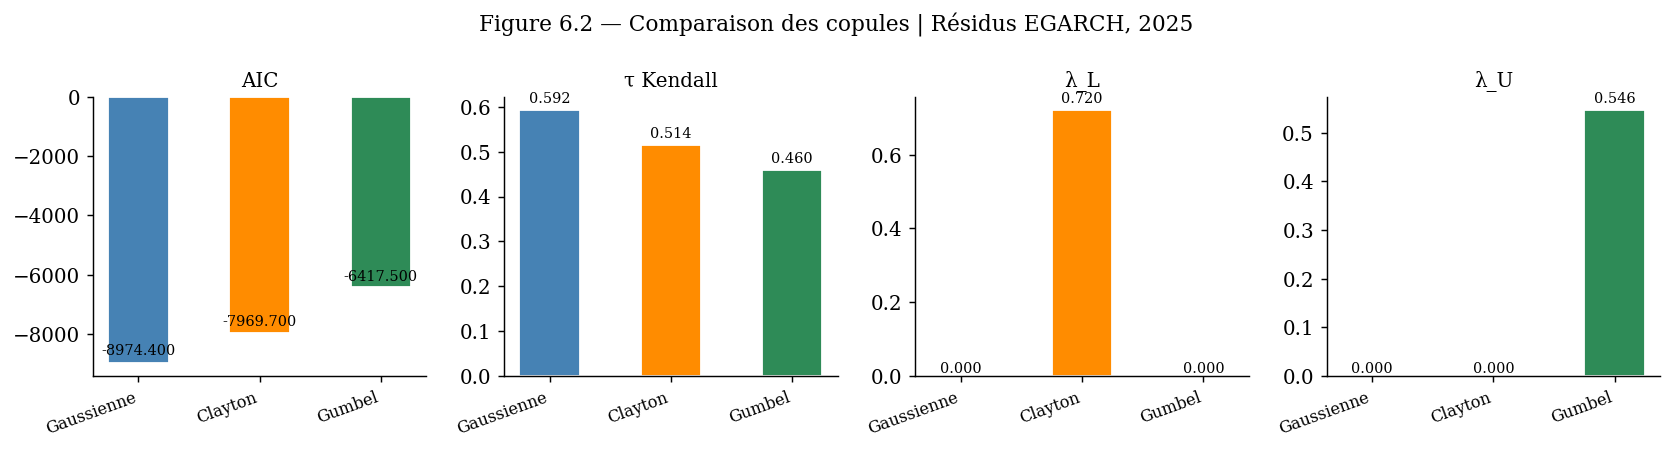

Figure 6.2 sauvegardée.


In [ ]:
metrics = ['AIC', 'τ Kendall', 'λ_L', 'λ_U']
colors  = {'Gaussienne': 'steelblue', 'Clayton': 'darkorange', 'Gumbel': 'seagreen'}

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for ax, metric in zip(axes, metrics):
    vals = tab_annual[metric]
    cols = [colors[n] for n in tab_annual.index]
    bars = ax.bar(tab_annual.index, vals, color=cols, edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=11)
    ax.set_xticklabels(tab_annual.index, rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        offset = abs(bar.get_height()) * 0.02
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + offset,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Figure 6.2 — Comparaison des copules | Résidus EGARCH, 2025', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig6_2_copula_comparison.pdf'), bbox_inches='tight')
plt.show()
print('Figure 6.2 sauvegardée.')

---
##  Dépendance conditionnelle : pré-crash / crash / post-crash

.

| Régime | Période | Observations |
|--------|---------|-------------|
| Pré-crash | 1–5 oct. 2025 | ~120 h |
| **Crash** | **6–12 oct. 2025** | **~168 h** |
| Post-crash | 13–31 oct. 2025 | ~456 h |


In [ ]:
REGIMES = {
    'Pré-crash'  : ('2025-10-01 00:00', '2025-10-05 23:00'),
    'Crash'      : ('2025-10-06 00:00', '2025-10-12 23:00'),
    'Post-crash' : ('2025-10-13 00:00', '2025-10-31 23:00'),
}

rows = []
for regime, (start, end) in REGIMES.items():
    mask  = (idx_aligned >= start) & (idx_aligned <= end)
    idx_r = np.where(mask)[0]
    if len(idx_r) < 20:
        print(f'[{regime}] trop peu d\'observations ({len(idx_r)}), ignoré.')
        continue

    zb, ze = z_btc[idx_r], z_eth[idx_r]
    ur, vr = pit(zb), pit(ze)
    rho_p  = np.corrcoef(zb, ze)[0, 1]

    print(f'\n── {regime} ({len(idx_r)} obs) | ρ_Pearson={rho_p:.3f} ──')
    for fn in FIT_FNS:
        r = fn(ur, vr)
        p_str = ', '.join(f'{k}={v_:.3f}' for k, v_ in r['params'].items())
        print(f"  {r['name']:12s}  AIC={r['aic']:9.1f}  τ={r['τ']:.3f}  "
              f"λ_L={r['λ_L']:.3f}  λ_U={r['λ_U']:.3f}  ({p_str})")
        rows.append({
            'Régime': regime, 'Copule': r['name'],
            'AIC': r['aic'], 'τ_Kendall': r['τ'],
            'λ_L': r['λ_L'], 'λ_U': r['λ_U'],
            'ρ_Pearson': rho_p,
            **r['params']
        })

cond_df = pd.DataFrame(rows)
print('\n=== Tableau synthèse Section 6.3 ===')
print(cond_df[['Régime','Copule','τ_Kendall','λ_L','λ_U','ρ_Pearson']].to_string(index=False))


── Pré-crash (120 obs) | ρ_Pearson=0.814 ──
  Gaussienne    AIC=   -112.0  τ=0.586  λ_L=0.000  λ_U=0.000  (ρ=0.795)
  Clayton       AIC=    -92.6  τ=0.490  λ_L=0.697  λ_U=0.000  (θ=1.922)
  Gumbel        AIC=    -87.0  τ=0.478  λ_L=0.000  λ_U=0.564  (θ=1.915)

── Crash (168 obs) | ρ_Pearson=0.797 ──
  Gaussienne    AIC=   -183.7  τ=0.619  λ_L=0.000  λ_U=0.000  (ρ=0.826)
  Clayton       AIC=   -156.3  τ=0.529  λ_L=0.734  λ_U=0.000  (θ=2.242)
  Gumbel        AIC=   -129.8  τ=0.509  λ_L=0.000  λ_U=0.595  (θ=2.037)

── Post-crash (456 obs) | ρ_Pearson=0.874 ──
  Gaussienne    AIC=   -653.0  τ=0.679  λ_L=0.000  λ_U=0.000  (ρ=0.876)
  Clayton       AIC=   -516.9  τ=0.569  λ_L=0.769  λ_U=0.000  (θ=2.643)
  Gumbel        AIC=   -421.4  τ=0.588  λ_L=0.000  λ_U=0.670  (θ=2.428)

=== Tableau synthèse Section 6.3 ===
    Régime     Copule  τ_Kendall      λ_L      λ_U  ρ_Pearson
 Pré-crash Gaussienne   0.585516 0.000000 0.000000   0.814268
 Pré-crash    Clayton   0.490041 0.697216 0.000000   0.814

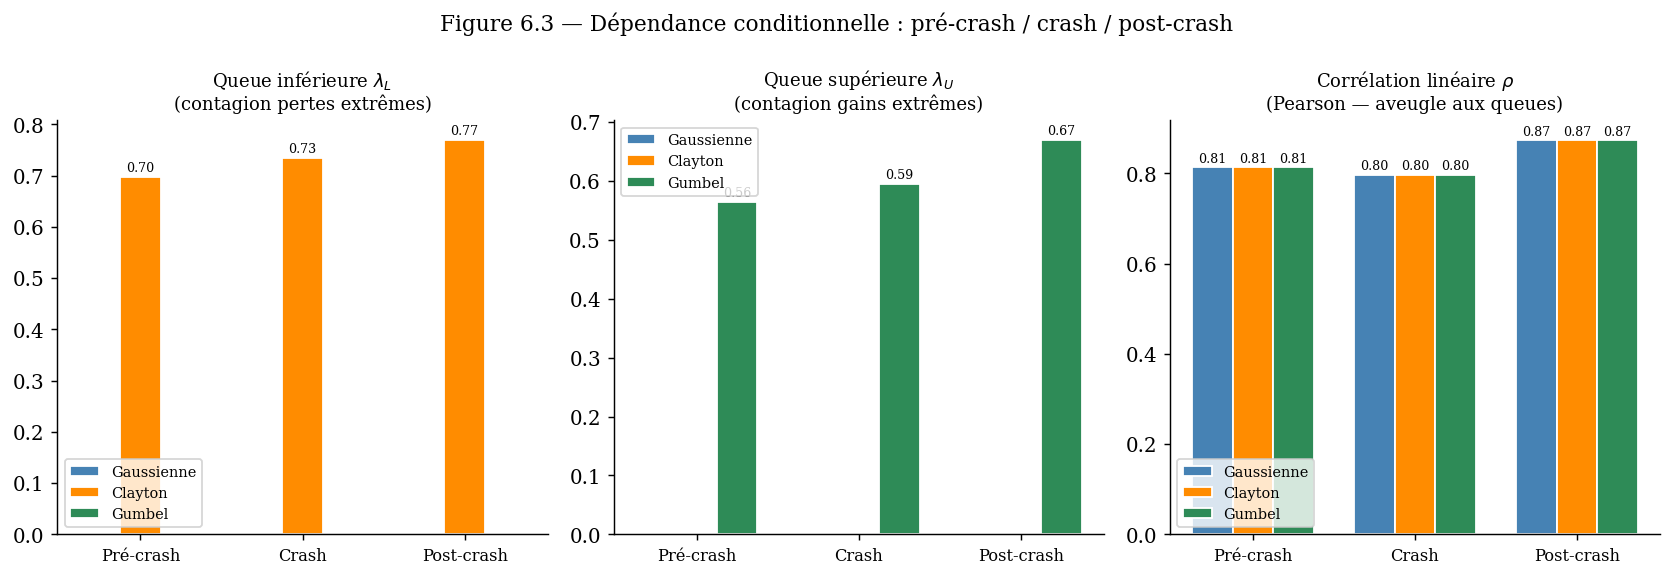

Figure 6.3 sauvegardée.


In [ ]:
regimes = list(REGIMES.keys())
copulas = ['Gaussienne', 'Clayton', 'Gumbel']
palette = {'Gaussienne': 'steelblue', 'Clayton': 'darkorange', 'Gumbel': 'seagreen'}

metrics_plot = ['λ_L', 'λ_U', 'ρ_Pearson']
titles_plot  = [
    'Queue inférieure $\\lambda_L$\n(contagion pertes extrêmes)',
    'Queue supérieure $\\lambda_U$\n(contagion gains extrêmes)',
    'Corrélation linéaire $\\rho$\n(Pearson — aveugle aux queues)'
]

x = np.arange(len(regimes))
width = 0.25
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, metric, title in zip(axes, metrics_plot, titles_plot):
    for i, cop in enumerate(copulas):
        sub  = cond_df[cond_df['Copule'] == cop]
        vals = []
        for reg in regimes:
            row = sub[sub['Régime'] == reg]
            vals.append(row[metric].values[0] if len(row) > 0 else np.nan)
        bars = ax.bar(x + i*width, vals, width, label=cop,
                      color=palette[cop], edgecolor='white')
        for bar, val in zip(bars, vals):
            if not np.isnan(val) and val > 0.01:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.005,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x + width)
    ax.set_xticklabels(regimes, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0)

fig.suptitle(
    'Figure 6.3 — Dépendance conditionnelle : pré-crash / crash / post-crash',
    fontsize=12
)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig6_3_conditional.pdf'), bbox_inches='tight')
plt.show()
print('Figure 6.3 sauvegardée.')